# 02 — Exploratory Data Analysis
Understand distributions, correlations and outliers.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/listings_raw.csv')

# Keep only relevant columns
cols = ['price', 'accommodates', 'bedrooms', 'bathrooms',
        'neighbourhood_cleansed', 'room_type', 'minimum_nights',
        'latitude', 'longitude', 'availability_365',
        'number_of_reviews', 'reviews_per_month']
df = df[cols].copy()
df.head()

,price,accommodates,bedrooms,bathrooms,neighbourhood_cleansed,room_type,minimum_nights,latitude,longitude,availability_365,number_of_reviews,reviews_per_month
0,NaN,4,1.0,NaN,Sihlfeld,Entire home/apt,1125,47.37167,8.51948,358,47,0.29
1,$232.00,2,1.0,1.5,Alt-Wiedikon,Entire home/apt,3,47.35761,8.52131,269,0,NaN
2,$48.00,1,1.0,1.0,Enge,Private room,5,47.36514,8.52615,92,9,0.05
3,$501.00,3,2.0,1.5,Escher Wyss,Entire home/apt,4,47.38942,8.51881,280,31,0.18
4,$160.00,4,2.0,1.0,Rathaus,Entire home/apt,4,47.37372,8.54452,13,383,2.30


In [14]:
# Clean price column (remove $ and commas)
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
df = df[df['price'] > 0].dropna(subset=['price'])
print(df['price'].describe())

count     2592.000000
mean       181.742670
std        328.257478
min         10.000000
25%         98.000000
50%        134.000000
75%        198.250000
max      10000.000000
Name: price, dtype: float64


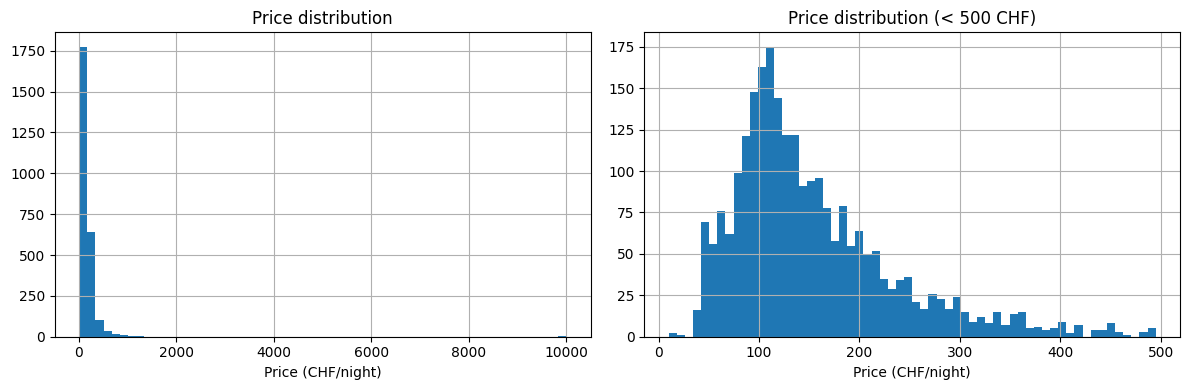

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['price'].hist(bins=60, ax=axes[0])
axes[0].set_title('Price distribution')
axes[0].set_xlabel('Price (CHF/night)')

df[df['price'] < 500]['price'].hist(bins=60, ax=axes[1])
axes[1].set_title('Price distribution (< 500 CHF)')
axes[1].set_xlabel('Price (CHF/night)')
plt.tight_layout()
plt.savefig('../reports/figures/price_distribution.png', dpi=150)
plt.show()

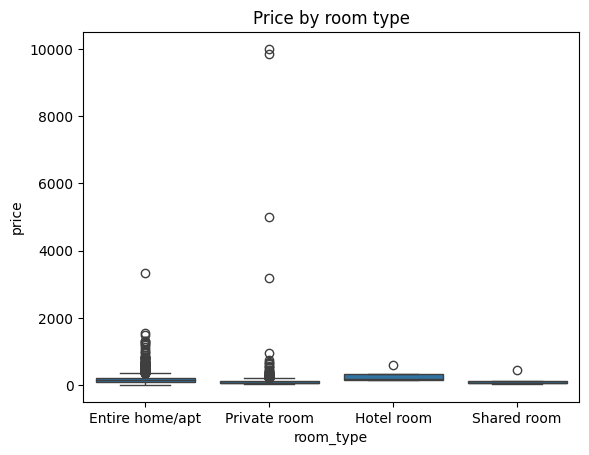

In [16]:
sns.boxplot(data=df, x='room_type', y='price')
plt.title('Price by room type')
plt.savefig('../reports/figures/price_by_room_type.png', dpi=150)
plt.show()

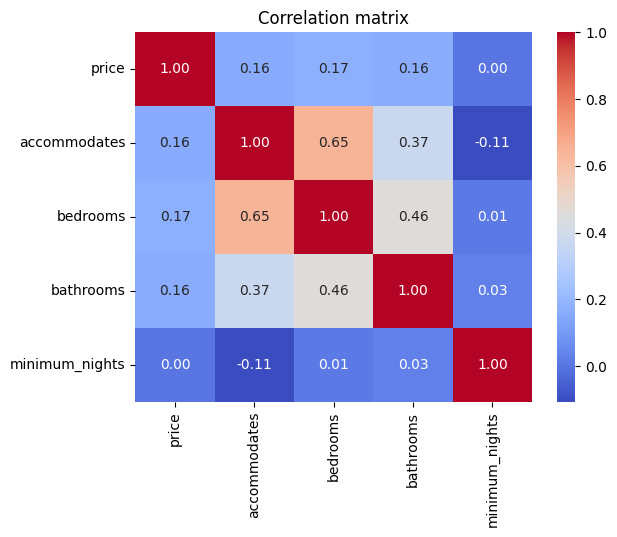

In [17]:
numeric = df[['price','accommodates','bedrooms','bathrooms','minimum_nights']]
sns.heatmap(numeric.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation matrix')
plt.savefig('../reports/figures/correlation_matrix.png', dpi=150)
plt.show()

In [18]:
df.to_csv('../data/processed/listings_eda.csv', index=False)
print('EDA dataset saved.')

EDA dataset saved.
